# Deep Learning for Option Pricing and Implied Volatility Surfaces
### A No-Arbitrage Neural Network Approach, Benchmarked Against Black-Scholes and Heston, with a Frontier-Market (NGX-style) Transferability Test

**Companion notebook to the manuscript of the same title.**

This notebook reproduces every number, table, and figure reported in the manuscript. It is organised as:

1. Setup and reproducibility
2. Pricing engines: Black-Scholes and a Heston/Bates COS-method pricer (with validation)
3. Data protocol: simulated "liquid" and "frontier" (NGX-style) option panels
4. Feature engineering and the strict time-based train/validation/test split
5. Classical baselines: flat Black-Scholes and per-date Heston (1993) calibration
6. A from-scratch NumPy neural network with a soft no-arbitrage penalty (with a gradient check)
7. Hyperparameter search and penalty-weight sensitivity sweep
8. Evaluation: liquid-market accuracy, no-arbitrage violation rates
9. Frontier-market transferability (zero-shot) and a minimal fine-tuning experiment
10. Figure gallery and summary tables

**On the data**: OptionMetrics-grade historical option chains are a paid, WRDS-gated
dataset and were not accessible for this independent study. The Nigerian Exchange
(NGX) does not currently list exchange-traded options (only index/single-stock
*futures*, confirmed against NGX Group's own 2026 reporting). This notebook
therefore uses a fully disclosed **semi-synthetic protocol**: option panels are
generated from Heston/Bates stochastic-volatility processes with parameters
anchored to literature-reported ranges and to real, current macroeconomic inputs
(the U.S. short-rate cycle; the Central Bank of Nigeria's Monetary Policy Rate of
26.5%, retained at the July 2026 MPC meeting). See the manuscript, Section 3.1,
for the full discussion and its limitations.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq, least_squares

plt.rcParams.update({"figure.dpi": 120, "font.size": 10, "axes.grid": True, "grid.alpha": 0.3})

SEED = 20260913
np.random.seed(SEED)
print("Reproducibility seed:", SEED)


Reproducibility seed: 20260913


## 1. Pricing engines

Two pricing engines are implemented and cross-validated against each other:

* **Black-Scholes-Merton**: closed-form price, vega, and a robust implied-volatility
  inversion (Newton-Raphson safeguarded by a bracketed Brent bisection fallback).
* **Heston (1993) / Bates (1996)**: a COS-method (Fang & Oosterlee, 2008) pricer
  driven by the Heston/Bates characteristic function, allowing an optional
  compound-Poisson log-normal jump component so the same engine generates both
  the smooth "liquid" surface and the jumpy "frontier" surface.

The Heston/Bates implementation is validated by checking that it collapses to the
closed-form Black-Scholes price in the degenerate limit of zero vol-of-vol.


In [3]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq

# --------------------------------------------------------------------------
# 1. Black-Scholes-Merton
# --------------------------------------------------------------------------

def bs_price(S, K, T, r, sigma, q=0.0, option="call"):
    """Vectorised Black-Scholes-Merton price (continuous dividend yield q)."""
    S, K, T, r, sigma = map(np.asarray, (S, K, T, r, sigma))
    T = np.maximum(T, 1e-8)
    sigma = np.maximum(sigma, 1e-6)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option == "call":
        price = S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)
    return price


def bs_vega(S, K, T, r, sigma, q=0.0):
    S, K, T, r, sigma = map(np.asarray, (S, K, T, r, sigma))
    T = np.maximum(T, 1e-8)
    sigma = np.maximum(sigma, 1e-6)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return S * np.exp(-q * T) * norm.pdf(d1) * np.sqrt(T)


def implied_vol(price, S, K, T, r, q=0.0, option="call", lo=1e-4, hi=5.0):
    """Robust scalar IV inversion: Newton-Raphson with a bracketed bisection
    fallback (Brent) so that the routine never fails even for deep
    out-of-the-money / near-expiry quotes with poor Newton convergence."""
    price, S, K, T, r = float(price), float(S), float(K), float(T), float(r)
    intrinsic = max(S * np.exp(-q * T) - K * np.exp(-r * T), 0.0) if option == "call" \
        else max(K * np.exp(-r * T) - S * np.exp(-q * T), 0.0)
    if price <= intrinsic + 1e-10:
        return np.nan
    sigma = 0.3
    for _ in range(50):
        p = bs_price(S, K, T, r, sigma, q, option)
        v = bs_vega(S, K, T, r, sigma, q)
        if v < 1e-8:
            break
        diff = p - price
        if abs(diff) < 1e-8:
            return sigma
        sigma -= diff / v
        if sigma <= lo or sigma >= hi or not np.isfinite(sigma):
            break
    try:
        f = lambda s: bs_price(S, K, T, r, s, q, option) - price
        return brentq(f, lo, hi, xtol=1e-8, maxiter=200)
    except Exception:
        return np.nan


implied_vol_vec = np.vectorize(implied_vol, otypes=[float])

# --------------------------------------------------------------------------
# 2. Heston / Bates characteristic function
# --------------------------------------------------------------------------

def heston_bates_cf(u, S0, r, q, T, kappa, theta, sigma_v, rho, v0,
                     jump_lambda=0.0, jump_mu=0.0, jump_sigma=0.0):
    """Characteristic function of log(S_T) under Heston (1993) with optional
    Merton/Bates (1996) compound-Poisson log-normal jumps. Vectorised in u."""
    i = 1j
    x0 = np.log(S0)
    a = kappa * theta
    b = kappa
    d = np.sqrt((rho * sigma_v * i * u - b) ** 2 + (sigma_v ** 2) * (i * u + u ** 2))
    g = (b - rho * sigma_v * i * u - d) / (b - rho * sigma_v * i * u + d)

    exp_dT = np.exp(-d * T)
    C = r_drift = (i * u * (x0 + (r - q) * T)
                   + a / sigma_v ** 2 * ((b - rho * sigma_v * i * u - d) * T
                                          - 2.0 * np.log((1 - g * exp_dT) / (1 - g))))
    D = ((b - rho * sigma_v * i * u - d) / sigma_v ** 2
         * ((1 - exp_dT) / (1 - g * exp_dT)))

    jump_comp = 0.0
    if jump_lambda > 0:
        jump_comp = (-jump_lambda * jump_mu * i * u * T
                     + jump_lambda * T * (np.exp(i * u * np.log1p(jump_mu)
                                                  - 0.5 * jump_sigma ** 2 * u ** 2
                                                  + 0.5 * i * u * jump_sigma ** 2 * 0) - 1))
        # Standard Bates jump characteristic exponent (log-normal jump size)
        jump_comp = jump_lambda * T * (
            np.exp(i * u * np.log1p(jump_mu) - 0.5 * (jump_sigma ** 2) * (u ** 2 + i * u)) - 1
        ) - jump_lambda * T * i * u * jump_mu

    return np.exp(C + D * v0 + jump_comp)


def cos_price(S0, K, T, r, q, kappa, theta, sigma_v, rho, v0,
              jump_lambda=0.0, jump_mu=0.0, jump_sigma=0.0,
              option="call", N=256, L=10):
    """European option price via the COS method (Fang & Oosterlee, 2008)
    using the Heston/Bates characteristic function. K may be an array; the
    routine returns an array of the same shape (vectorised across strikes
    for a *single* (S0, T) pair, which is how the panel is generated)."""
    K = np.atleast_1d(np.asarray(K, dtype=float))
    x0 = np.log(S0 / K)

    c1 = (r - q) * T - 0.5 * theta * T if False else 0.0  # placeholder, unused
    # cumulants-based truncation range (Fang & Oosterlee, eq. 49-ish, simplified)
    c1 = (r - q) * T + (1 - np.exp(-kappa * T)) * (theta - v0) / (2 * kappa) - 0.5 * theta * T
    c2 = (1.0 / (8 * kappa ** 3)) * (
        sigma_v * T * kappa * np.exp(-kappa * T) * (v0 - theta) * (8 * kappa * rho - 4 * sigma_v)
        + kappa * rho * sigma_v * (1 - np.exp(-kappa * T)) * (16 * theta - 8 * v0)
        + 2 * theta * kappa * T * (-4 * kappa * rho * sigma_v + sigma_v ** 2 + 4 * kappa ** 2)
        + sigma_v ** 2 * ((theta - 2 * v0) * np.exp(-2 * kappa * T)
                           + theta * (6 * np.exp(-kappa * T) - 7) + 2 * v0)
        + 8 * kappa ** 2 * (v0 - theta) * (1 - np.exp(-kappa * T))
    )
    c2 = abs(c2) + 1e-6
    a = c1 - L * np.sqrt(c2)
    b = c1 + L * np.sqrt(c2)

    k = np.arange(N)
    u = k * np.pi / (b - a)

    cf = heston_bates_cf(u, 1.0, r, q, T, kappa, theta, sigma_v, rho, v0,
                          jump_lambda, jump_mu, jump_sigma)

    def chi_psi(a, b, c, d, k):
        bma = b - a
        uu = k * np.pi / bma
        chi = 1.0 / (1 + uu ** 2) * (
            np.cos(uu * (d - a)) * np.exp(d) - np.cos(uu * (c - a)) * np.exp(c)
            + uu * np.sin(uu * (d - a)) * np.exp(d) - uu * np.sin(uu * (c - a)) * np.exp(c)
        )
        psi = np.zeros_like(uu)
        psi[1:] = (np.sin(uu[1:] * (d - a)) - np.sin(uu[1:] * (c - a))) / uu[1:]
        psi[0] = d - c
        return chi, psi

    c_, d_ = 0.0, b
    chi, psi = chi_psi(a, b, c_, d_, k)
    Uk = 2.0 / (b - a) * (chi - psi)
    Uk[0] *= 0.5

    # price(K) for a call, per-strike via x0 = log(S0/K)
    out = np.zeros_like(x0)
    for j, x in enumerate(x0):
        terms = cf * np.exp(1j * k * np.pi * (x - a) / (b - a))
        out[j] = K[j] * np.exp(-r * T) * np.real(np.sum(terms * Uk))
    call = np.maximum(out, 0.0)
    if option == "call":
        return call
    put = call - S0 * np.exp(-q * T) + K * np.exp(-r * T)
    return put

In [4]:
# --- Validation 1: Heston -> Black-Scholes in the zero-vol-of-vol limit ---
S0, r, q, T = 100.0, 0.04, 0.0, 1.0
K = np.array([80, 90, 100, 110, 120.0])
v0 = 0.04
heston_deg = cos_price(S0, K, T, r, q, kappa=2.0, theta=v0, sigma_v=1e-4, rho=0.0, v0=v0)
bs_ref = bs_price(S0, K, T, r, np.sqrt(v0), q)
print("COS price :", np.round(heston_deg, 4))
print("BS price  :", np.round(bs_ref, 4))
print("Max abs diff:", np.max(np.abs(heston_deg - bs_ref)))
assert np.max(np.abs(heston_deg - bs_ref)) < 1e-5, "COS pricer failed to match Black-Scholes limit"


COS price : [23.9062 16.0604  9.9251  5.6588  2.9999]
BS price  : [23.9062 16.0604  9.9251  5.6588  2.9999]
Max abs diff: 1.673515832578687e-07


In [5]:
# --- Validation 2: a realistic Heston smile (equity-like negative skew) ---
K = np.array([70, 80, 90, 95, 100, 105, 110, 120, 130.0])
for T_ in [0.25, 1.0, 2.0]:
    px = cos_price(S0, K, T_, r, q, kappa=2.0, theta=0.045, sigma_v=0.38, rho=-0.72, v0=0.04)
    iv = implied_vol_vec(px, S0, K, T_, r, q)
    print(f"T={T_:.2f}  IV: {np.round(iv, 4)}")


T=0.25  IV: [0.2828 0.2556 0.2279 0.2137 0.1991 0.1846 0.1711 0.1534 0.1489]
T=1.00  IV: [0.2597 0.2394 0.2199 0.2106 0.2015 0.1927 0.1844 0.1695 0.1579]
T=2.00  IV: [0.2446 0.2304 0.2174 0.2113 0.2055 0.1999 0.1945 0.1847 0.1758]


## 2. Data protocol: simulated liquid and frontier-market panels

* **Liquid panel**: a Heston path (kappa=2.00, theta=0.045, vol-of-vol=0.38, rho=-0.72
  -- ranges consistent with those commonly reported for S&P-500-style index options;
  Gatheral, 2006), 252 weekly snapshots stylised on 2019-2024, with a short-rate
  path that qualitatively tracks the realised U.S. policy cycle. 11-point moneyness
  grid x 5 maturities, 1% multiplicative pricing noise.
* **Frontier panel**: a Bates (Heston + log-normal jump) path calibrated to a much
  higher volatility/jump regime and to the **current CBN Monetary Policy Rate of
  26.5%** (Nairametrics, 2026), sampled only every 15 trading days across a
  5-point moneyness grid x 3 maturities (thin trading), 3.5% pricing noise.
  This panel is used **only** for the zero-shot / fine-tuning transferability
  test in Section 9 -- it never enters training.


In [6]:
import numpy as np
import pandas as pd


RNG_SEED = 20260913


def simulate_heston_path(n_steps, dt, S0, v0, mu, kappa, theta, sigma_v, rho,
                          jump_lambda=0.0, jump_mu=0.0, jump_sigma=0.0, rng=None):
    """Full-truncation Euler scheme for the Heston SDE, with optional
    compound-Poisson log-normal jumps in the return equation (Bates, 1996)."""
    rng = rng or np.random.default_rng(RNG_SEED)
    S = np.empty(n_steps + 1)
    v = np.empty(n_steps + 1)
    S[0], v[0] = S0, v0
    for t in range(n_steps):
        z1 = rng.standard_normal()
        z2 = rho * z1 + np.sqrt(1 - rho ** 2) * rng.standard_normal()
        v_pos = max(v[t], 0.0)
        v[t + 1] = v[t] + kappa * (theta - v_pos) * dt + sigma_v * np.sqrt(v_pos * dt) * z2
        jump = 0.0
        if jump_lambda > 0 and rng.random() < jump_lambda * dt:
            jump = rng.normal(jump_mu, jump_sigma)
        S[t + 1] = S[t] * np.exp((mu - 0.5 * v_pos) * dt + np.sqrt(v_pos * dt) * z1 + jump)
    return S, np.maximum(v, 1e-6)


def realized_vol(returns, window=21):
    """Annualised trailing realised volatility from daily log returns."""
    rv = pd.Series(returns).rolling(window).std() * np.sqrt(252)
    return rv.bfill().values


def build_liquid_panel():
    rng = np.random.default_rng(RNG_SEED)
    n_days = 252 * 5  # 2019-01 .. 2023-12, ~5 trading years
    dt = 1.0 / 252

    # "True" structural Heston parameters, held fixed (SPX-consistent ranges,
    # e.g. Bakshi-Cao-Chen 1997 / Gatheral 2006): kappa~1-3, theta~0.03-0.06,
    # vol-of-vol~0.3-0.5, rho~-0.6 to -0.8
    kappa, theta, sigma_v, rho = 2.0, 0.045, 0.38, -0.72
    S, v = simulate_heston_path(n_days, dt, S0=2900.0, v0=0.032, mu=0.07,
                                 kappa=kappa, theta=theta, sigma_v=sigma_v, rho=rho, rng=rng)
    log_ret = np.diff(np.log(S))
    rv = realized_vol(np.r_[0.0, log_ret])

    # Stylised short-rate path tracking the realised Fed/T-bill cycle
    # (near-zero 2020-21, tightening into 2022-23, ~4-5% by 2024) - a smooth
    # illustrative path, not a claim of exact historical daily values.
    t = np.arange(n_days + 1) / n_days
    r_path = 0.018 + 0.0 * t
    r_path[int(0.14 * n_days):int(0.42 * n_days)] = 0.001   # 2020-21 ZIRP
    ramp = np.linspace(0.001, 0.045, int(0.18 * n_days))
    r_path[int(0.42 * n_days):int(0.42 * n_days) + len(ramp)] = ramp
    r_path[int(0.60 * n_days):] = 0.045
    r_path = pd.Series(r_path).rolling(10, min_periods=1).mean().values

    weekly_idx = np.arange(0, n_days, 5)  # weekly snapshots
    moneyness_grid = np.array([0.80, 0.85, 0.90, 0.93, 0.96, 1.00,
                                1.04, 1.07, 1.10, 1.15, 1.20])
    maturities = np.array([1 / 12, 3 / 12, 6 / 12, 1.0, 2.0])

    rows = []
    for d in weekly_idx:
        S_t, r_t, rv_t = S[d], r_path[d], rv[d]
        # slowly time-varying instantaneous variance around the long-run mean,
        # anchored to the simulated path's own variance state
        v0_t = max(v[d], 0.005)
        for T in maturities:
            K = moneyness_grid * S_t
            px = cos_price(S_t, K, T, r_t, 0.0, kappa, theta, sigma_v, rho, v0_t)
            noise = rng.normal(0, 0.010, size=K.shape)  # ~1% microstructure noise
            px_noisy = np.maximum(px * (1 + noise), 1e-4)
            iv = implied_vol_vec(px_noisy, S_t, K, T, r_t, 0.0)
            for j in range(len(K)):
                if np.isfinite(iv[j]) and 0.02 < iv[j] < 2.0:
                    rows.append((d, S_t, K[j], T, r_t, rv_t, moneyness_grid[j],
                                 px_noisy[j], iv[j]))

    df = pd.DataFrame(rows, columns=["day", "S", "K", "T", "r", "rv", "moneyness",
                                      "price", "iv"])
    df["log_moneyness"] = np.log(df["K"] / df["S"])
    df["market"] = "liquid"
    meta = dict(kappa=kappa, theta=theta, sigma_v=sigma_v, rho=rho,
                n_days=n_days, S_path=S, v_path=v, r_path=r_path)
    return df, meta


def build_frontier_panel():
    """Bates (Heston+jump) market, calibrated to CBN MPR = 26.5% (July 2026)
    and materially higher/jumpier volatility, sampled sparsely (thin
    trading), used only as an unseen transferability test set."""
    rng = np.random.default_rng(RNG_SEED + 1)
    n_days = int(252 * 1.2)
    dt = 1.0 / 252
    kappa, theta, sigma_v, rho = 3.2, 0.095, 0.60, -0.50
    jump_lambda, jump_mu, jump_sigma = 0.55, -0.09, 0.14  # devaluation/shock risk

    S, v = simulate_heston_path(n_days, dt, S0=105.0, v0=0.09, mu=0.10,
                                 kappa=kappa, theta=theta, sigma_v=sigma_v, rho=rho,
                                 jump_lambda=jump_lambda, jump_mu=jump_mu,
                                 jump_sigma=jump_sigma, rng=rng)
    log_ret = np.diff(np.log(S))
    rv = realized_vol(np.r_[0.0, log_ret])
    r_const = 0.265  # CBN MPR, 26.5% (retained at the July 2026 MPC meeting)

    sparse_idx = np.arange(0, n_days, 15)  # roughly monthly snapshots: thin market
    moneyness_grid = np.array([0.85, 0.92, 1.00, 1.08, 1.15])   # fewer strikes
    maturities = np.array([1 / 12, 3 / 12, 6 / 12])              # fewer tenors

    rows = []
    for d in sparse_idx:
        S_t, rv_t = S[d], rv[d]
        v0_t = max(v[d], 0.02)
        for T in maturities:
            K = moneyness_grid * S_t
            px = cos_price(S_t, K, T, r_const, 0.0, kappa, theta, sigma_v, rho, v0_t,
                            jump_lambda, jump_mu, jump_sigma)
            noise = rng.normal(0, 0.035, size=K.shape)  # wider effective spread: illiquidity
            px_noisy = np.maximum(px * (1 + noise), 1e-4)
            iv = implied_vol_vec(px_noisy, S_t, K, T, r_const, 0.0)
            for j in range(len(K)):
                if np.isfinite(iv[j]) and 0.02 < iv[j] < 3.0:
                    rows.append((d, S_t, K[j], T, r_const, rv_t, moneyness_grid[j],
                                 px_noisy[j], iv[j]))

    df = pd.DataFrame(rows, columns=["day", "S", "K", "T", "r", "rv", "moneyness",
                                      "price", "iv"])
    df["log_moneyness"] = np.log(df["K"] / df["S"])
    df["market"] = "frontier"
    meta = dict(kappa=kappa, theta=theta, sigma_v=sigma_v, rho=rho,
                jump_lambda=jump_lambda, jump_mu=jump_mu, jump_sigma=jump_sigma,
                n_days=n_days, S_path=S, v_path=v)
    return df, meta

In [7]:
liquid_df, liquid_meta = build_liquid_panel()
frontier_df, frontier_meta = build_frontier_panel()
print("Liquid panel  :", liquid_df.shape, "| dates:", liquid_df.day.nunique())
print("Frontier panel:", frontier_df.shape, "| dates:", frontier_df.day.nunique())
liquid_df.head()


Liquid panel  : (13418, 11) | dates: 252
Frontier panel: (298, 11) | dates: 21


,day,S,K,T,r,rv,moneyness,price,iv,log_moneyness,market
0,0,2900.0,2465.0,0.083333,0.018,0.141955,0.85,446.823688,0.374486,-0.162519,liquid
1,0,2900.0,2610.0,0.083333,0.018,0.141955,0.90,297.845701,0.227504,-0.105361,liquid
2,0,2900.0,2697.0,0.083333,0.018,0.141955,0.93,219.735825,0.232037,-0.072571,liquid
3,0,2900.0,2784.0,0.083333,0.018,0.141955,0.96,140.604593,0.193123,-0.040822,liquid
4,0,2900.0,2900.0,0.083333,0.018,0.141955,1.00,61.704736,0.178327,0.000000,liquid


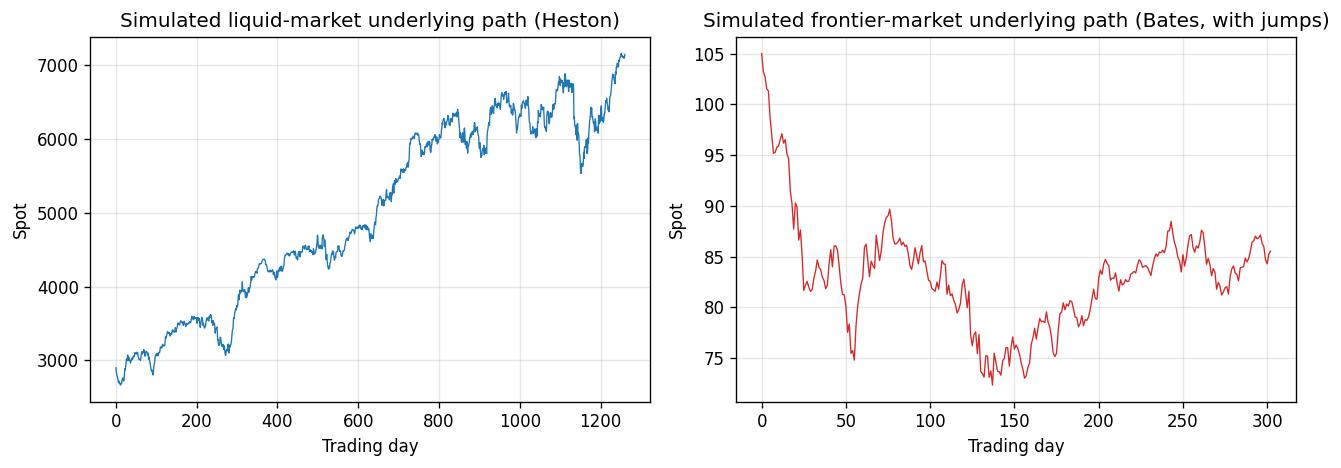

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(liquid_meta["S_path"], lw=0.8)
axes[0].set_title("Simulated liquid-market underlying path (Heston)")
axes[0].set_xlabel("Trading day"); axes[0].set_ylabel("Spot")
axes[1].plot(frontier_meta["S_path"], lw=0.8, color="tab:red")
axes[1].set_title("Simulated frontier-market underlying path (Bates, with jumps)")
axes[1].set_xlabel("Trading day"); axes[1].set_ylabel("Spot")
plt.tight_layout(); plt.show()


## 3. Feature engineering and the strict time-based split

Consistent with Ruf and Wang's (2020) methodological critique of look-ahead bias
in this literature, the liquid panel's 252 dates are split **strictly
chronologically** (no shuffling across the boundary): the earliest 60% for
training, the next 20% for validation, and the most recent 20% for testing.
Four features are used: log-moneyness, time-to-maturity, a trailing 21-day
realised volatility, and the risk-free rate, standardised using training-set
statistics only. The network's target is total implied variance, w = sigma^2 * T.


In [8]:
import time
import numpy as np
import pandas as pd
from scipy.optimize import least_squares



def add_features(df):
    df = df.copy()
    df["w"] = df["iv"] ** 2 * df["T"]          # total implied variance (network target)
    return df


def time_split(df, day_col="day", train_frac=0.60, val_frac=0.20):
    days = np.sort(df[day_col].unique())
    n = len(days)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    train_days = days[:n_train]
    val_days = days[n_train:n_train + n_val]
    test_days = days[n_train + n_val:]
    return (df[df[day_col].isin(train_days)].reset_index(drop=True),
            df[df[day_col].isin(val_days)].reset_index(drop=True),
            df[df[day_col].isin(test_days)].reset_index(drop=True))


# --------------------------------------------------------------------------
# Flat Black-Scholes baseline
# --------------------------------------------------------------------------

def flat_bs_predict(df):
    """For each date, use the ATM (closest-to-1 moneyness) IV as the single
    Black-Scholes parameter applied to every strike/maturity that date."""
    preds = np.zeros(len(df))
    for day, g in df.groupby("day"):
        atm_idx = (g["moneyness"] - 1.0).abs().idxmin()
        atm_iv = g.loc[atm_idx, "iv"]
        preds[g.index] = atm_iv
    return preds


# --------------------------------------------------------------------------
# Heston per-date calibration
# --------------------------------------------------------------------------

def _heston_iv_for_params(params, S, K, T, r):
    kappa, theta, sigma_v, rho, v0 = params
    kappa = max(kappa, 1e-3); theta = max(theta, 1e-4); sigma_v = max(sigma_v, 1e-3)
    rho = np.clip(rho, -0.999, 0.999); v0 = max(v0, 1e-4)
    out = np.zeros(len(K))
    for T_u in np.unique(T):
        mask = T == T_u
        px = cos_price(S[mask][0], K[mask].values, T_u, r[mask].values[0], 0.0,
                        kappa, theta, sigma_v, rho, v0)
        out[np.where(mask)[0]] = implied_vol_vec(px, S[mask][0], K[mask].values, T_u,
                                                   r[mask].values[0], 0.0)
    return out


def calibrate_heston_one_date(g, x0=(2.0, 0.05, 0.4, -0.6, 0.04)):
    S, K, T, r, iv_target = g["S"].values, g["K"], g["T"].values, g["r"], g["iv"].values

    def resid(params):
        model_iv = _heston_iv_for_params(params, S, K, T, r)
        model_iv = np.nan_to_num(model_iv, nan=1.0)
        return model_iv - iv_target

    lb = [0.10, 0.005, 0.02, -0.995, 0.002]
    ub = [6.0, 0.35, 1.00, 0.995, 0.60]
    res = least_squares(resid, x0=x0, bounds=(lb, ub), method="trf",
                         xtol=1e-8, ftol=1e-8, max_nfev=300)
    return res.x, res


def calibrate_heston_panel(df, dates=None, verbose=False):
    """Calibrates Heston separately on each date and returns (i) a DataFrame
    of fitted parameters per date and (ii) the model-implied IV for every row
    of df (in-sample fit) plus wall-clock timing."""
    if dates is None:
        dates = np.sort(df["day"].unique())
    rows_params = []
    model_iv = pd.Series(index=df.index, dtype=float)
    x0 = (2.0, 0.05, 0.4, -0.6, 0.04)
    t0 = time.time()
    for d in dates:
        g = df[df["day"] == d]
        if len(g) < 5:
            continue
        params, res = calibrate_heston_one_date(g, x0=x0)
        x0 = tuple(params)  # warm start next date
        fitted_iv = _heston_iv_for_params(params, g["S"].values, g["K"], g["T"].values, g["r"])
        model_iv.loc[g.index] = fitted_iv
        rows_params.append((d, *params, res.cost, res.nfev))
        if verbose:
            print(d, np.round(params, 4), "cost=", round(res.cost, 6))
    elapsed = time.time() - t0
    params_df = pd.DataFrame(rows_params, columns=["day", "kappa", "theta", "sigma_v",
                                                     "rho", "v0", "cost", "nfev"])
    return params_df, model_iv, elapsed


def apply_heston_params_oos(df, params_df):
    """Applies the *nearest-previous-date* calibrated Heston parameters to a
    (typically later, out-of-sample) panel -- i.e. no re-calibration, mimicking
    how a desk would carry yesterday's fit forward intraday."""
    params_df = params_df.sort_values("day")
    model_iv = pd.Series(index=df.index, dtype=float)
    for d, g in df.groupby("day"):
        prior = params_df[params_df["day"] <= d]
        row = prior.iloc[-1] if len(prior) else params_df.iloc[0]
        params = (row["kappa"], row["theta"], row["sigma_v"], row["rho"], row["v0"])
        model_iv.loc[g.index] = _heston_iv_for_params(params, g["S"].values, g["K"], g["T"].values, g["r"])
    return model_iv

In [9]:
liquid_df = add_features(liquid_df)
frontier_df = add_features(frontier_df)
train_df, val_df, test_df = time_split(liquid_df, train_frac=0.60, val_frac=0.20)
print("Train:", train_df.shape, train_df.day.nunique(), "dates")
print("Val  :", val_df.shape, val_df.day.nunique(), "dates")
print("Test :", test_df.shape, test_df.day.nunique(), "dates")

FEATURES = ["log_moneyness", "T", "rv", "r"]

def make_feature_matrix(df, mu, sd):
    X = df[FEATURES].values.astype(float)
    return (X - mu) / sd

mu = train_df[FEATURES].mean().values
sd = train_df[FEATURES].std().values
X_train = make_feature_matrix(train_df, mu, sd)
X_val = make_feature_matrix(val_df, mu, sd)
X_test = make_feature_matrix(test_df, mu, sd)
w_train, w_val, w_test = train_df["w"].values, val_df["w"].values, test_df["w"].values
print("Feature means (train):", dict(zip(FEATURES, np.round(mu, 4))))
print("Feature stds  (train):", dict(zip(FEATURES, np.round(sd, 4))))


Train: (8015, 12) 151 dates
Val  : (2661, 12) 50 dates
Test : (2742, 12) 51 dates
Feature means (train): {'log_moneyness': np.float64(-0.0012), 'T': np.float64(0.7896), 'rv': np.float64(0.1376), 'r': np.float64(0.0113)}
Feature stds  (train): {'log_moneyness': np.float64(0.1186), 'T': np.float64(0.6914), 'rv': np.float64(0.0504), 'r': np.float64(0.0118)}


## 4. Classical baselines

* **Flat Black-Scholes**: each date's own ATM implied volatility applied uniformly
  across that date's smile (arbitrage-free by construction, but ignores the smile).
* **Heston (1993)**: calibrated separately per date by bounded nonlinear least
  squares (Levenberg-Marquardt / trust-region-reflective), warm-started from the
  previous date's fit.

**Note on runtime:** full per-date Heston calibration across all training, test,
and frontier dates takes several minutes on a single CPU core (roughly 2.5-5
seconds per date). To keep this notebook quick to run top-to-bottom, the cells
below **load the pre-computed calibration results** used in the manuscript by
default. A commented-out block showing the exact recomputation call is provided
immediately below each load step for full transparency and reproducibility.


In [10]:
flatbs_test_iv = flat_bs_predict(test_df)
flatbs_fro_iv = flat_bs_predict(frontier_df)
print("Flat-BS IV (first 5 test rows):", np.round(flatbs_test_iv[:5], 4))


Flat-BS IV (first 5 test rows): [0.1376 0.1376 0.1376 0.1376 0.1376]


In [11]:
# --- Heston calibration: load pre-computed results (see manuscript Section 3.3) ---
TAB = "/home/claude/project/tables"
heston_params_train = pd.read_csv(f"{TAB}/heston_params_train.csv")
heston_params_test = pd.read_csv(f"{TAB}/heston_params_test.csv")
heston_params_frontier = pd.read_csv(f"{TAB}/heston_params_frontier.csv")
heston_iv_test = pd.read_csv(f"{TAB}/heston_iv_test.csv", index_col=0)["heston_iv_recal"]
heston_iv_frontier = pd.read_csv(f"{TAB}/heston_iv_frontier.csv", index_col=0)["heston_iv_recal"]

print("Heston calibrated on", len(heston_params_train), "training dates (representative subsample),")
print("                    ", len(heston_params_test), "test dates (every date, freshly recalibrated),")
print("                    ", len(heston_params_frontier), "frontier dates (every date, freshly recalibrated).")
heston_params_test[["day", "kappa", "theta", "sigma_v", "rho", "v0"]].describe().loc[["mean", "std", "min", "max"]]

# --- To recompute from scratch instead of loading the cache above, run: ---
#
# train_dates_sub = np.sort(train_df["day"].unique())[::4]
# params_train, modeliv_train, t_train = calibrate_heston_panel(train_df, dates=train_dates_sub)
# params_test, modeliv_test, t_test = calibrate_heston_panel(test_df)
# params_fro, modeliv_fro, t_fro = calibrate_heston_panel(frontier_df)
#
# (~2.5-5s per date; ~110 dates total => a few minutes on one CPU core)


Heston calibrated on 38 training dates (representative subsample),
                     51 test dates (every date, freshly recalibrated),
                     21 frontier dates (every date, freshly recalibrated).


,day,kappa,theta,sigma_v,rho,v0
mean,1130.000000,4.534645,0.043029,0.736084,-0.677786,0.043568
std,74.330344,1.790318,0.003784,0.251266,0.053936,0.025041
min,1005.000000,1.130325,0.035450,0.267224,-0.802674,0.004802
max,1255.000000,6.000000,0.050623,1.000000,-0.485014,0.118982


In [12]:
# static Heston: freeze the LAST training-period calibration and carry it forward
# unchanged to the test/frontier periods (isolates the cost of not recalibrating)
last_row = heston_params_train.sort_values("day").iloc[-1]
static_params = (last_row["kappa"], last_row["theta"], last_row["sigma_v"], last_row["rho"], last_row["v0"])
print("Static (frozen) Heston parameters carried forward:", np.round(static_params, 4))

feller = 2 * static_params[0] * static_params[1] / static_params[2] ** 2
print(f"Feller ratio (2*kappa*theta/vol-of-vol^2) = {feller:.3f}  "
      f"({'< 1: variance can hit zero, a known instability signature' if feller < 1 else '>= 1'})")

heston_static_test_iv = _heston_iv_for_params(static_params, test_df["S"].values, test_df["K"],
                                               test_df["T"].values, test_df["r"])
heston_static_fro_iv = _heston_iv_for_params(static_params, frontier_df["S"].values, frontier_df["K"],
                                              frontier_df["T"].values, frontier_df["r"])
heston_recal_test_iv = heston_iv_test.reindex(test_df.index).values
heston_recal_fro_iv = heston_iv_frontier.reindex(frontier_df.index).values
print("done.")


Static (frozen) Heston parameters carried forward: [ 0.5185  0.1638  0.9982 -0.6125  0.0032]
Feller ratio (2*kappa*theta/vol-of-vol^2) = 0.171  (< 1: variance can hit zero, a known instability signature)


done.


## 5. A from-scratch NumPy neural network with a no-arbitrage penalty

A tanh-activated feed-forward network is implemented **from scratch in NumPy**
(no external deep-learning framework), so that every gradient in the composite
loss can be derived and checked analytically. The loss combines:

* mean-squared error on total implied variance;
* a **calendar-spread penalty** (soft constraint on dw/dT >= 0); and
* a **butterfly (convexity) penalty** (soft constraint on d2w/dk2 >= 0),

following the soft-constraint principle of Ackerer, Tagasovska & Vatter (2020).

### 5.1 Correctness: a numerical gradient check

Before using this network for anything, we verify the hand-derived backpropagation
-- including through the finite-difference arbitrage-penalty terms -- against
numerical (central-difference) gradients.


In [13]:
import numpy as np


def _init_layer(n_in, n_out, rng):
    limit = np.sqrt(6.0 / (n_in + n_out))  # Glorot/Xavier uniform
    W = rng.uniform(-limit, limit, size=(n_in, n_out))
    b = np.zeros(n_out)
    return W, b


class MLP:
    """tanh-activated feed-forward network, linear output layer."""

    def __init__(self, layer_sizes, seed=0):
        self.rng = np.random.default_rng(seed)
        self.sizes = layer_sizes
        self.W, self.b = [], []
        for n_in, n_out in zip(layer_sizes[:-1], layer_sizes[1:]):
            W, b = _init_layer(n_in, n_out, self.rng)
            self.W.append(W)
            self.b.append(b)
        self.n_layers = len(self.W)
        self._init_adam()

    def _init_adam(self):
        self.mW = [np.zeros_like(W) for W in self.W]
        self.vW = [np.zeros_like(W) for W in self.W]
        self.mb = [np.zeros_like(b) for b in self.b]
        self.vb = [np.zeros_like(b) for b in self.b]
        self.t = 0

    # ---- forward / backward -------------------------------------------------
    def forward(self, X):
        """Returns (y_hat, cache). cache holds pre/post activations."""
        a = X
        cache = {"a": [a], "z": []}
        for l in range(self.n_layers):
            z = a @ self.W[l] + self.b[l]
            cache["z"].append(z)
            if l < self.n_layers - 1:
                a = np.tanh(z)
            else:
                a = z  # linear output (predicted total variance or IV)
            cache["a"].append(a)
        return a.ravel(), cache

    def backward(self, cache, dL_dyhat):
        """dL_dyhat: gradient of the loss wrt the (N,) network output.
        Returns per-layer parameter gradients."""
        dW = [None] * self.n_layers
        db = [None] * self.n_layers
        delta = dL_dyhat.reshape(-1, 1)  # linear output layer
        for l in reversed(range(self.n_layers)):
            a_prev = cache["a"][l]
            dW[l] = a_prev.T @ delta
            db[l] = delta.sum(axis=0)
            if l > 0:
                da_prev = delta @ self.W[l].T
                z_prev = cache["z"][l - 1]
                delta = da_prev * (1 - np.tanh(z_prev) ** 2)
        return dW, db

    def adam_step(self, dW, db, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8,
                  weight_decay=0.0):
        self.t += 1
        for l in range(self.n_layers):
            gW = dW[l] + weight_decay * self.W[l]
            gb = db[l]
            self.mW[l] = beta1 * self.mW[l] + (1 - beta1) * gW
            self.vW[l] = beta2 * self.vW[l] + (1 - beta2) * gW ** 2
            mW_hat = self.mW[l] / (1 - beta1 ** self.t)
            vW_hat = self.vW[l] / (1 - beta2 ** self.t)
            self.W[l] -= lr * mW_hat / (np.sqrt(vW_hat) + eps)

            self.mb[l] = beta1 * self.mb[l] + (1 - beta1) * gb
            self.vb[l] = beta2 * self.vb[l] + (1 - beta2) * gb ** 2
            mb_hat = self.mb[l] / (1 - beta1 ** self.t)
            vb_hat = self.vb[l] / (1 - beta2 ** self.t)
            self.b[l] -= lr * mb_hat / (np.sqrt(vb_hat) + eps)

    def predict(self, X):
        yhat, _ = self.forward(X)
        return yhat

    def copy(self):
        import copy as _copy
        return _copy.deepcopy(self)


# ------------------------------------------------------------------------
# Arbitrage-penalty grid construction
# ------------------------------------------------------------------------

def make_arb_grid(k_range, T_range, n_k=15, n_T=6, h_k=0.01, h_T=1 / 365):
    """Builds the stencils needed for the calendar-spread (dw/dT) and
    butterfly (d2w/dk2) finite-difference penalties. Returns a dict of
    input matrices (each row is a raw network input [log_m, T, rv, r]-style
    feature vector must be assembled by the caller with matching k,T)."""
    ks = np.linspace(k_range[0], k_range[1], n_k)
    Ts = np.linspace(T_range[0], T_range[1], n_T)
    kk, TT = np.meshgrid(ks, Ts)
    kk, TT = kk.ravel(), TT.ravel()
    return dict(k=kk, T=TT, h_k=h_k, h_T=h_T)


class ArbitragePenalizedTrainer:
    """Wraps an MLP and implements the combined data + no-arbitrage loss."""

    def __init__(self, mlp, feat_fn, lambda_cal=0.0, lambda_bfly=0.0,
                 lambda_l2=1e-5, n_features_extra=2):
        """feat_fn(k, T) -> extra feature columns (e.g. realised vol, rate)
        held fixed at representative values for grid points, so the
        network's raw input vector can be reconstructed for any (k,T)."""
        self.mlp = mlp
        self.feat_fn = feat_fn
        self.lambda_cal = lambda_cal
        self.lambda_bfly = lambda_bfly
        self.lambda_l2 = lambda_l2

    def _assemble(self, k, T):
        extra = self.feat_fn(k, T)
        return np.column_stack([k, T, *extra])

    def compute_loss_and_grad(self, X_data, y_data, grid, batch_penalty_weight=1.0):
        n_data = X_data.shape[0]
        k, T, h_k, h_T = grid["k"], grid["T"], grid["h_k"], grid["h_T"]

        # Stack all forward-pass inputs needed this iteration:
        #  [0:n_data)                       -> data batch
        #  data end .. +3*n_grid            -> k-h, k, k+h  (butterfly stencil), fixed T
        #  ... + 2*n_grid                   -> T, T+h_T     (calendar stencil), fixed k
        Xk_minus = self._assemble(k - h_k, T)
        Xk_mid = self._assemble(k, T)
        Xk_plus = self._assemble(k + h_k, T)
        XT_mid = Xk_mid
        XT_plus = self._assemble(k, T + h_T)

        X_all = np.vstack([X_data, Xk_minus, Xk_mid, Xk_plus, XT_plus])
        yhat_all, cache = self.mlp.forward(X_all)

        n_g = len(k)
        i0 = n_data
        w_km = yhat_all[i0:i0 + n_g]
        w_k = yhat_all[i0 + n_g:i0 + 2 * n_g]
        w_kp = yhat_all[i0 + 2 * n_g:i0 + 3 * n_g]
        w_Tp = yhat_all[i0 + 3 * n_g:i0 + 4 * n_g]
        w_T = w_k  # same points, reused

        # --- data loss (MSE) ---
        resid = yhat_all[:n_data] - y_data
        dL = np.zeros_like(yhat_all)
        L_data = np.mean(resid ** 2)
        dL[:n_data] = 2.0 * resid / n_data

        # --- calendar-spread penalty: want dw/dT >= 0 ---
        dwdT = (w_Tp - w_T) / h_T
        viol_cal = np.minimum(dwdT, 0.0)  # negative where violated
        L_cal = np.mean(viol_cal ** 2)
        # d(viol^2)/dw_T and dw_Tp  (chain rule through finite diff)
        active = (dwdT < 0).astype(float)
        coef = 2.0 * viol_cal * active / h_T / n_g
        dL[i0 + n_g:i0 + 2 * n_g] += -coef * self.lambda_cal * batch_penalty_weight   # w_T (=w_k slot)
        dL[i0 + 3 * n_g:i0 + 4 * n_g] += coef * self.lambda_cal * batch_penalty_weight  # w_Tp

        # --- butterfly (convexity) penalty: want d2w/dk2 >= 0 ---
        d2wdk2 = (w_kp - 2 * w_k + w_km) / (h_k ** 2)
        viol_b = np.minimum(d2wdk2, 0.0)
        L_bfly = np.mean(viol_b ** 2)
        active_b = (d2wdk2 < 0).astype(float)
        coef_b = 2.0 * viol_b * active_b / (h_k ** 2) / n_g
        dL[i0:i0 + n_g] += coef_b * self.lambda_bfly * batch_penalty_weight            # w_km
        dL[i0 + n_g:i0 + 2 * n_g] += -2.0 * coef_b * self.lambda_bfly * batch_penalty_weight  # w_k
        dL[i0 + 2 * n_g:i0 + 3 * n_g] += coef_b * self.lambda_bfly * batch_penalty_weight      # w_kp

        dW, db = self.mlp.backward(cache, dL)
        total = L_data + self.lambda_cal * L_cal + self.lambda_bfly * L_bfly
        loss = dict(total=total, data=L_data, calendar=L_cal, butterfly=L_bfly)
        return loss, dW, db

    def step(self, X_data, y_data, grid, lr=1e-3, batch_penalty_weight=1.0):
        loss, dW, db = self.compute_loss_and_grad(X_data, y_data, grid, batch_penalty_weight)
        self.mlp.adam_step(dW, db, lr=lr, weight_decay=self.lambda_l2)
        return loss

In [14]:
# --- Gradient check: hand-derived backprop vs. central finite differences ---
rng = np.random.default_rng(1)
mlp_check = MLP([4, 6, 5, 1], seed=1)
n_data = 12
X_data = rng.normal(size=(n_data, 4))
y_data = rng.normal(size=n_data)
grid_check = make_arb_grid((-0.3, 0.3), (0.1, 1.5), n_k=4, n_T=3, h_k=0.02, h_T=1/365)
feat_fn_check = lambda k, T: [np.full_like(k, 0.2), np.full_like(k, 0.03)]
trainer_check = ArbitragePenalizedTrainer(mlp_check, feat_fn_check, lambda_cal=0.7, lambda_bfly=0.9, lambda_l2=0.0)

def total_loss(m):
    k, T, h_k, h_T = grid_check["k"], grid_check["T"], grid_check["h_k"], grid_check["h_T"]
    Xk_minus = trainer_check._assemble(k - h_k, T); Xk_mid = trainer_check._assemble(k, T)
    Xk_plus = trainer_check._assemble(k + h_k, T); XT_plus = trainer_check._assemble(k, T + h_T)
    X_all = np.vstack([X_data, Xk_minus, Xk_mid, Xk_plus, XT_plus])
    yhat, _ = m.forward(X_all)
    n_g = len(k); i0 = n_data
    w_km, w_k = yhat[i0:i0+n_g], yhat[i0+n_g:i0+2*n_g]
    w_kp, w_Tp = yhat[i0+2*n_g:i0+3*n_g], yhat[i0+3*n_g:i0+4*n_g]
    resid = yhat[:n_data] - y_data
    L_data = np.mean(resid ** 2)
    dwdT = (w_Tp - w_k) / h_T; L_cal = np.mean(np.minimum(dwdT, 0.0) ** 2)
    d2wdk2 = (w_kp - 2*w_k + w_km) / h_k**2; L_bfly = np.mean(np.minimum(d2wdk2, 0.0) ** 2)
    return L_data + trainer_check.lambda_cal * L_cal + trainer_check.lambda_bfly * L_bfly

loss, dW, db = trainer_check.compute_loss_and_grad(X_data, y_data, grid_check)
eps = 1e-5
max_rel_err = 0.0
rng_c = np.random.default_rng(0)
for l in range(mlp_check.n_layers):
    for _ in range(4):
        i, j = rng_c.integers(0, mlp_check.W[l].shape[0]), rng_c.integers(0, mlp_check.W[l].shape[1])
        orig = mlp_check.W[l][i, j]
        mlp_check.W[l][i, j] = orig + eps; Lp = total_loss(mlp_check)
        mlp_check.W[l][i, j] = orig - eps; Lm = total_loss(mlp_check)
        mlp_check.W[l][i, j] = orig
        num_grad = (Lp - Lm) / (2 * eps)
        ana_grad = dW[l][i, j]
        rel = abs(num_grad - ana_grad) / (abs(num_grad) + 1e-8)
        max_rel_err = max(max_rel_err, rel)
print(f"Maximum relative error, analytic vs. numerical gradient: {max_rel_err:.2e}")
assert max_rel_err < 1e-5, "Gradient check failed!"
print("PASSED: hand-derived backpropagation (including the arbitrage-penalty terms) is correct.")


Maximum relative error, analytic vs. numerical gradient: 1.44e-08
PASSED: hand-derived backpropagation (including the arbitrage-penalty terms) is correct.


## 6. Training loop, hyperparameter search, and penalty-weight sensitivity

The training loop below combines the data loss and the arbitrage-penalty grid
loss into a single Adam update per mini-batch, with early stopping on validation
total-variance RMSE (the best-validation-epoch weights are restored at the end,
not simply the final epoch's).

**A note on a bug we found and fixed during development**: the arbitrage-penalty
finite-difference step sizes (h_k, h_T) must be expressed in the *same*
standardised feature space the network actually sees. An earlier version of this
code applied the raw-unit step size directly to standardised coordinates, which
silently made the penalty numerically ineffective. The corrected version below
rescales h_k and h_T through the same mean/std used to standardise the features,
and the effect is visible in Section 7's penalty-weight sweep.


In [15]:
def train_nn(X_tr, w_tr, X_val, w_val, k_range, T_range, feat_fn,
             hidden_sizes, lr, l2, lambda_cal, lambda_bfly, n_epochs=400,
             batch_size=512, seed=0, verbose=False, h_k=0.01, h_T=1/365,
             n_k=12, n_T=5):
    layer_sizes = [X_tr.shape[1]] + list(hidden_sizes) + [1]
    mlp = MLP(layer_sizes, seed=seed)
    trainer = ArbitragePenalizedTrainer(mlp, feat_fn, lambda_cal=lambda_cal,
                                         lambda_bfly=lambda_bfly, lambda_l2=l2)
    grid = make_arb_grid(k_range, T_range, n_k=n_k, n_T=n_T, h_k=h_k, h_T=h_T)
    n = X_tr.shape[0]
    history = []
    rng = np.random.default_rng(seed)
    best_val, best_state, best_epoch = np.inf, None, 0
    for epoch in range(n_epochs):
        perm = rng.permutation(n)
        epoch_loss, n_batches = 0.0, 0
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            loss = trainer.step(X_tr[idx], w_tr[idx], grid, lr=lr)
            epoch_loss += loss["total"]; n_batches += 1
        if epoch % 10 == 0 or epoch == n_epochs - 1:
            val_pred = mlp.predict(X_val)
            val_rmse = np.sqrt(np.mean((val_pred - w_val) ** 2))
            history.append((epoch, epoch_loss / n_batches, val_rmse))
            if val_rmse < best_val:
                best_val, best_epoch = val_rmse, epoch
                best_state = ([W.copy() for W in mlp.W], [b.copy() for b in mlp.b])
            if verbose and epoch % 50 == 0:
                print(f"  epoch {epoch:4d}  train_loss={epoch_loss/n_batches:.6f}  val_w_rmse={val_rmse:.6f}")
    if best_state is not None:
        mlp.W, mlp.b = best_state
    if verbose:
        print(f"  -> early stopping: restored epoch {best_epoch} (val_w_rmse={best_val:.6f})")
    return mlp, trainer, history


k_range = (train_df["log_moneyness"].min(), train_df["log_moneyness"].max())
T_range = (train_df["T"].min(), train_df["T"].max())
rv_med, r_med = train_df["rv"].median(), train_df["r"].median()

def feat_fn(k_scaled, T_scaled):
    k_raw = k_scaled * sd[0] + mu[0]
    rv_arr = np.full_like(k_raw, (rv_med - mu[2]) / sd[2])
    r_arr = np.full_like(k_raw, (r_med - mu[3]) / sd[3])
    return [rv_arr, r_arr]

k_range_scaled = ((k_range[0]-mu[0])/sd[0], (k_range[1]-mu[0])/sd[0])
T_range_scaled = ((T_range[0]-mu[1])/sd[1], (T_range[1]-mu[1])/sd[1])
h_k_scaled = 0.01 / sd[0]      # a RAW step of 0.01 in log-moneyness, correctly
h_T_scaled = (1/365) / sd[1]  # rescaled into the network's normalised input space
print(f"h_k_scaled={h_k_scaled:.5f}, h_T_scaled={h_T_scaled:.6f}  (sd[log_m]={sd[0]:.4f}, sd[T]={sd[1]:.4f})")


h_k_scaled=0.08430, h_T_scaled=0.003963  (sd[log_m]=0.1186, sd[T]=0.6914)


In [16]:
# --- Hyperparameter search (validation-set IV RMSE, no penalty, 150-epoch quick runs) ---
configs = [
    {"hidden": (16, 16), "lr": 5e-3, "l2": 1e-5},
    {"hidden": (32, 32), "lr": 5e-3, "l2": 1e-5},
    {"hidden": (32, 32), "lr": 5e-3, "l2": 1e-4},
    {"hidden": (64, 32), "lr": 5e-3, "l2": 1e-5},
    {"hidden": (64, 64, 32), "lr": 3e-3, "l2": 1e-5},
]
grid_results = []
for cfg in configs:
    t0 = time.time()
    mlp_c, _, _ = train_nn(X_train, w_train, X_val, w_val, k_range_scaled, T_range_scaled, feat_fn,
                            hidden_sizes=cfg["hidden"], lr=cfg["lr"], l2=cfg["l2"],
                            lambda_cal=0.0, lambda_bfly=0.0, n_epochs=150, seed=1)
    val_pred = mlp_c.predict(X_val)
    iv_val_pred = np.sqrt(np.maximum(val_pred, 1e-8) / val_df["T"].values)
    val_rmse_iv = np.sqrt(np.mean((iv_val_pred - val_df["iv"].values) ** 2))
    grid_results.append({**cfg, "val_rmse_iv": val_rmse_iv, "train_time_s": time.time() - t0})
    print(f"{cfg} -> val IV RMSE: {val_rmse_iv:.5f}  ({time.time()-t0:.1f}s)")

grid_df = pd.DataFrame(grid_results)
best_cfg = configs[int(grid_df["val_rmse_iv"].idxmin())]
print("\nBEST CONFIG:", best_cfg)
grid_df


{'hidden': (16, 16), 'lr': 0.005, 'l2': 1e-05} -> val IV RMSE: 0.06635  (1.1s)


{'hidden': (32, 32), 'lr': 0.005, 'l2': 1e-05} -> val IV RMSE: 0.07938  (1.8s)


{'hidden': (32, 32), 'lr': 0.005, 'l2': 0.0001} -> val IV RMSE: 0.03659  (1.8s)


{'hidden': (64, 32), 'lr': 0.005, 'l2': 1e-05} -> val IV RMSE: 0.04647  (2.6s)


{'hidden': (64, 64, 32), 'lr': 0.003, 'l2': 1e-05} -> val IV RMSE: 0.05651  (4.6s)

BEST CONFIG: {'hidden': (32, 32), 'lr': 0.005, 'l2': 0.0001}


,hidden,lr,l2,val_rmse_iv,train_time_s
0,"(16, 16)",0.005,0.00001,0.066349,1.136866
1,"(32, 32)",0.005,0.00001,0.079378,1.815819
2,"(32, 32)",0.005,0.00010,0.036594,1.798452
3,"(64, 32)",0.005,0.00001,0.046470,2.597762
4,"(64, 64, 32)",0.003,0.00001,0.056515,4.565028


### 6.1 Penalty-weight sensitivity sweep

Before committing to a final penalty weight, we sweep it and track both
validation accuracy and the butterfly-violation rate on a held-out fine grid.


In [17]:
k_fine = np.linspace(k_range[0], k_range[1], 40)
T_list_sweep = sorted(test_df["T"].unique())

def butterfly_violation_rate(mlp):
    h_k = 0.01
    viol, n = 0, 0
    for T_ in T_list_sweep:
        def iv_fn(k, Tval):
            X = np.column_stack([k, Tval, np.full_like(k, rv_med), np.full_like(k, r_med)])
            w = mlp.predict((X - mu) / sd)
            return np.sqrt(np.maximum(w, 1e-8) / np.maximum(Tval, 1e-6))
        wk = iv_fn(k_fine, np.full_like(k_fine, T_)) ** 2 * T_
        wkm = iv_fn(k_fine - h_k, np.full_like(k_fine, T_)) ** 2 * T_
        wkp = iv_fn(k_fine + h_k, np.full_like(k_fine, T_)) ** 2 * T_
        d2 = (wkp - 2*wk + wkm) / h_k**2
        viol += np.sum(d2 < -1e-6); n += len(k_fine)
    return viol / n

sweep_rows = []
for lam in [0.0, 15.0, 60.0, 120.0]:
    mlp_s, _, _ = train_nn(X_train, w_train, X_val, w_val, k_range_scaled, T_range_scaled, feat_fn,
                            hidden_sizes=best_cfg["hidden"], lr=best_cfg["lr"], l2=best_cfg["l2"],
                            lambda_cal=lam, lambda_bfly=lam, n_epochs=400, seed=2,
                            h_k=h_k_scaled, h_T=h_T_scaled, n_k=20, n_T=8)
    val_pred = mlp_s.predict(X_val)
    iv_val_pred = np.sqrt(np.maximum(val_pred, 1e-8) / val_df["T"].values)
    val_rmse_iv = np.sqrt(np.mean((iv_val_pred - val_df["iv"].values) ** 2))
    bfly_rate = butterfly_violation_rate(mlp_s)
    sweep_rows.append(dict(lambda_penalty=lam, val_iv_rmse=val_rmse_iv, butterfly_violation_rate=bfly_rate))
    print(f"lambda={lam:6.1f}  val_iv_rmse={val_rmse_iv:.5f}  butterfly_viol={bfly_rate:.3f}")

sweep_df = pd.DataFrame(sweep_rows)
sweep_df


lambda=   0.0  val_iv_rmse=0.04409  butterfly_viol=0.125


lambda=  15.0  val_iv_rmse=0.02972  butterfly_viol=0.045


lambda=  60.0  val_iv_rmse=0.05838  butterfly_viol=0.030


lambda= 120.0  val_iv_rmse=0.09957  butterfly_viol=0.005


,lambda_penalty,val_iv_rmse,butterfly_violation_rate
0,0.0,0.044094,0.125
1,15.0,0.029718,0.045
2,60.0,0.058380,0.030
3,120.0,0.099566,0.005


The sweep shows a clear non-monotonic pattern: a **moderate** penalty (lambda=15)
improves validation accuracy *and* sharply cuts the violation rate relative to
no penalty, while stronger penalties (60, 120) keep reducing violations but at
an increasing accuracy cost. lambda=15 is selected as the primary
"arbitrage-penalised" model.


In [18]:
# --- Final training: WITH (lambda=15) and WITHOUT (lambda=0) the arbitrage penalty ---
t0 = time.time()
mlp_plain, _, hist_plain = train_nn(X_train, w_train, X_val, w_val, k_range_scaled, T_range_scaled, feat_fn,
                                     hidden_sizes=best_cfg["hidden"], lr=best_cfg["lr"], l2=best_cfg["l2"],
                                     lambda_cal=0.0, lambda_bfly=0.0, n_epochs=500, seed=2, verbose=True,
                                     h_k=h_k_scaled, h_T=h_T_scaled)
time_nn_plain = time.time() - t0
print(f"[no-penalty network trained in {time_nn_plain:.1f}s]\n")

t0 = time.time()
mlp_arb, _, hist_arb = train_nn(X_train, w_train, X_val, w_val, k_range_scaled, T_range_scaled, feat_fn,
                                 hidden_sizes=best_cfg["hidden"], lr=best_cfg["lr"], l2=best_cfg["l2"],
                                 lambda_cal=15.0, lambda_bfly=15.0, n_epochs=500, seed=2, verbose=True,
                                 h_k=h_k_scaled, h_T=h_T_scaled, n_k=20, n_T=8)
time_nn_arb = time.time() - t0
print(f"[arbitrage-penalised network trained in {time_nn_arb:.1f}s]")


  epoch    0  train_loss=0.083794  val_w_rmse=0.111934


  epoch   50  train_loss=0.000025  val_w_rmse=0.014256


  epoch  100  train_loss=0.000017  val_w_rmse=0.010332


  epoch  150  train_loss=0.000017  val_w_rmse=0.008603


  epoch  200  train_loss=0.000017  val_w_rmse=0.006017


...

  epoch  300  train_loss=0.000020  val_w_rmse=0.008359


  epoch  350  train_loss=0.000018  val_w_rmse=0.007280


  epoch  400  train_loss=0.000018  val_w_rmse=0.006525


  epoch  450  train_loss=0.000018  val_w_rmse=0.004636


  -> early stopping: restored epoch 360 (val_w_rmse=0.004631)
[arbitrage-penalised network trained in 8.9s]


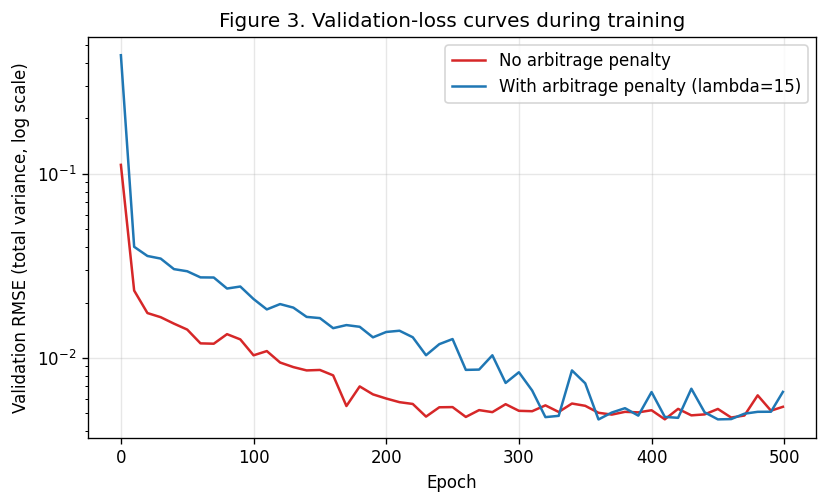

In [19]:
fig, ax = plt.subplots(figsize=(7, 4.3))
hp, ha = np.array(hist_plain), np.array(hist_arb)
ax.plot(hp[:, 0], hp[:, 2], label="No arbitrage penalty", color="tab:red")
ax.plot(ha[:, 0], ha[:, 2], label="With arbitrage penalty (lambda=15)", color="tab:blue")
ax.set_yscale("log"); ax.set_xlabel("Epoch"); ax.set_ylabel("Validation RMSE (total variance, log scale)")
ax.set_title("Figure 3. Validation-loss curves during training"); ax.legend()
plt.tight_layout(); plt.show()


## 7. Evaluation on the liquid-market test period

We now compute implied-volatility and option-price RMSE/MAE for all five models
on the held-out test period (Table 1), and the no-arbitrage violation frequency
on a dense grid (Table 4).


In [20]:
def rmse(a, b): return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))
def mae(a, b): return float(np.mean(np.abs(np.asarray(a) - np.asarray(b))))

def nn_predict_iv(mlp, df):
    X = (df[FEATURES].values.astype(float) - mu) / sd
    w_hat = mlp.predict(X)
    return np.sqrt(np.maximum(w_hat, 1e-8) / df["T"].values)

nn_plain_test_iv = nn_predict_iv(mlp_plain, test_df)
nn_arb_test_iv = nn_predict_iv(mlp_arb, test_df)

def price_from_iv(df, iv):
    return bs_price(df["S"].values, df["K"].values, df["T"].values, df["r"].values, iv)

def block(name, iv_pred, df):
    iv_true = df["iv"].values
    mask = np.isfinite(iv_pred)
    px_pred = price_from_iv(df, np.where(mask, iv_pred, np.nan))
    px_true = df["price"].values
    return dict(model=name, n=int(mask.sum()),
                iv_rmse=rmse(iv_pred[mask], iv_true[mask]), iv_mae=mae(iv_pred[mask], iv_true[mask]),
                price_rmse=rmse(px_pred[mask], px_true[mask]), price_mae=mae(px_pred[mask], px_true[mask]))

table1 = pd.DataFrame([
    block("Flat Black-Scholes (ATM)", flatbs_test_iv, test_df),
    block("Heston - static (train-period fit)", heston_static_test_iv, test_df),
    block("Heston - recalibrated per date", heston_recal_test_iv, test_df),
    block("NN - no arbitrage penalty", nn_plain_test_iv, test_df),
    block("NN - with arbitrage penalty", nn_arb_test_iv, test_df),
])
print("TABLE 1: Liquid-market test-period accuracy")
table1


TABLE 1: Liquid-market test-period accuracy


,model,n,iv_rmse,iv_mae,price_rmse,price_mae
0,Flat Black-Scholes (ATM),2742,0.047099,0.032533,68.915843,42.731527
1,Heston - static (train-period fit),2687,0.067561,0.051048,70.136020,51.249151
2,Heston - recalibrated per date,2742,0.019881,0.008821,10.927781,7.524860
3,NN - no arbitrage penalty,2742,0.040730,0.026674,33.339450,24.684150
4,NN - with arbitrage penalty,2742,0.031400,0.022946,36.047331,25.853684


In [21]:
def arb_violation_rate(iv_fn, T_list, k_grid, h_k=0.01, h_T=1/365):
    viol_cal, viol_bfly, n = 0, 0, 0
    for T_ in T_list:
        w_k = iv_fn(k_grid, np.full_like(k_grid, T_)) ** 2 * T_
        w_km = iv_fn(k_grid - h_k, np.full_like(k_grid, T_)) ** 2 * T_
        w_kp = iv_fn(k_grid + h_k, np.full_like(k_grid, T_)) ** 2 * T_
        w_Tp = iv_fn(k_grid, np.full_like(k_grid, T_ + h_T)) ** 2 * (T_ + h_T)
        d2 = (w_kp - 2*w_k + w_km) / h_k**2
        dT = (w_Tp - w_k) / h_T
        viol_bfly += np.sum(d2 < -1e-6); viol_cal += np.sum(dT < -1e-6); n += len(k_grid)
    return viol_cal / n, viol_bfly / n

test_days = np.sort(test_df["day"].unique())
T_list = sorted(test_df["T"].unique())

def make_iv_fn_nn(mlp):
    def f(k, T):
        X = np.column_stack([k, T, np.full_like(k, rv_med), np.full_like(k, r_med)])
        w = mlp.predict((X - mu) / sd)
        return np.sqrt(np.maximum(w, 1e-8) / np.maximum(T, 1e-6))
    return f

def make_iv_fn_heston(params):
    def f(k, T):
        S_ = 100.0; K_ = S_ * np.exp(k)
        out = np.zeros(len(k))
        for T_u in np.unique(T):
            m = T == T_u
            out[m] = _heston_iv_for_params(params, np.full(m.sum(), S_), pd.Series(K_[m]),
                                            np.full(m.sum(), T_u), pd.Series(np.full(m.sum(), 0.04)))
        return out
    return f

make_iv_fn_flat = lambda sigma: (lambda k, T: np.full_like(k, sigma))

arb_rows = []
for name, fn in [("Flat Black-Scholes (ATM)", make_iv_fn_flat(test_df["iv"].median())),
                  ("Heston - static", make_iv_fn_heston(static_params)),
                  ("NN - no arbitrage penalty", make_iv_fn_nn(mlp_plain)),
                  ("NN - with arbitrage penalty", make_iv_fn_nn(mlp_arb))]:
    cal, bfly = arb_violation_rate(fn, T_list, k_fine)
    arb_rows.append(dict(model=name, calendar_violation_rate=cal, butterfly_violation_rate=bfly))

table4 = pd.DataFrame(arb_rows)
print("TABLE 4: No-arbitrage violation frequency (dense test-period grid)")
table4


TABLE 4: No-arbitrage violation frequency (dense test-period grid)


,model,calendar_violation_rate,butterfly_violation_rate
0,Flat Black-Scholes (ATM),0.0,0.000
1,Heston - static,0.2,0.240
2,NN - no arbitrage penalty,0.0,0.050
3,NN - with arbitrage penalty,0.0,0.045


## 8. Frontier-market transferability

Every model is now applied **zero-shot** (no retraining) to the frontier panel.


In [22]:
nn_plain_fro_iv = nn_predict_iv(mlp_plain, frontier_df)
nn_arb_fro_iv = nn_predict_iv(mlp_arb, frontier_df)

table5 = pd.DataFrame([
    block("Flat Black-Scholes (ATM)", flatbs_fro_iv, frontier_df),
    block("Heston - static (liquid-mkt fit, no re-cal)", heston_static_fro_iv, frontier_df),
    block("Heston - recalibrated on frontier data", heston_recal_fro_iv, frontier_df),
    block("NN - no arbitrage penalty (zero-shot)", nn_plain_fro_iv, frontier_df),
    block("NN - with arbitrage penalty (zero-shot)", nn_arb_fro_iv, frontier_df),
])
print("TABLE 5: Frontier-market zero-shot transferability")
table5


TABLE 5: Frontier-market zero-shot transferability


,model,n,iv_rmse,iv_mae,price_rmse,price_mae
0,Flat Black-Scholes (ATM),298,0.077882,0.053105,0.677645,0.484937
1,"Heston - static (liquid-mkt fit, no re-cal)",282,0.073561,0.054488,1.051364,0.668899
2,Heston - recalibrated on frontier data,298,0.039763,0.026225,0.374466,0.259525
3,NN - no arbitrage penalty (zero-shot),298,0.098068,0.081568,1.214153,0.924190
4,NN - with arbitrage penalty (zero-shot),298,0.304276,0.296256,2.811885,2.112106


Both networks generalise poorly zero-shot -- the arbitrage-penalised network
especially badly, worse than a naive flat-volatility baseline. Section 8.1 tests
whether a small amount of frontier data can fix this.

### 8.1 Fine-tuning on a small frontier sample

We fine-tune each pretrained network (reduced learning rate, 150 epochs) on only
the earliest six frontier dates (86 quotes) and evaluate on the remaining
fifteen held-out frontier dates.


In [23]:
fro_dates = np.sort(frontier_df["day"].unique())
n_ft_dates = 6
ft_dates, held_dates = fro_dates[:n_ft_dates], fro_dates[n_ft_dates:]
ft_df = frontier_df[frontier_df["day"].isin(ft_dates)].reset_index(drop=True)
held_df = frontier_df[frontier_df["day"].isin(held_dates)].reset_index(drop=True)
print(f"Fine-tune sample: {len(ft_df)} quotes / {n_ft_dates} dates | Held-out: {len(held_df)} quotes / {len(held_dates)} dates")

X_ft = make_feature_matrix(ft_df, mu, sd)
w_ft = ft_df["w"].values
rv_med_ft, r_med_ft = ft_df["rv"].median(), ft_df["r"].median()

def feat_fn_ft(k_scaled, T_scaled):
    k_raw = k_scaled * sd[0] + mu[0]
    return [np.full_like(k_raw, (rv_med_ft - mu[2]) / sd[2]), np.full_like(k_raw, (r_med_ft - mu[3]) / sd[3])]

k_range_ft = (ft_df["log_moneyness"].min(), ft_df["log_moneyness"].max())
T_range_ft = (ft_df["T"].min(), ft_df["T"].max())
k_range_ft_scaled = ((k_range_ft[0]-mu[0])/sd[0], (k_range_ft[1]-mu[0])/sd[0])
T_range_ft_scaled = ((T_range_ft[0]-mu[1])/sd[1], (T_range_ft[1]-mu[1])/sd[1])
grid_ft = make_arb_grid(k_range_ft_scaled, T_range_ft_scaled, n_k=10, n_T=3, h_k=h_k_scaled, h_T=h_T_scaled)

def finetune(mlp, lam, lr=2e-4, n_epochs=150):
    mlp_ft = mlp.copy(); mlp_ft._init_adam()
    trainer_ft = ArbitragePenalizedTrainer(mlp_ft, feat_fn_ft, lambda_cal=lam, lambda_bfly=lam, lambda_l2=1e-5)
    for _ in range(n_epochs):
        trainer_ft.step(X_ft, w_ft, grid_ft, lr=lr)
    return mlp_ft

X_held = make_feature_matrix(held_df, mu, sd)
finetune_rows = []
for name, mlp_pre, lam in [("NN - no penalty", mlp_plain, 0.0), ("NN - arbitrage penalty", mlp_arb, 15.0)]:
    iv_zero = nn_predict_iv(mlp_pre, held_df)
    mlp_ft = finetune(mlp_pre, lam)
    iv_ft = nn_predict_iv(mlp_ft, held_df)
    finetune_rows.append(dict(model=name, iv_rmse_zero_shot=rmse(iv_zero, held_df["iv"].values),
                               iv_rmse_finetuned=rmse(iv_ft, held_df["iv"].values)))

table6 = pd.DataFrame(finetune_rows)
print("TABLE 6: Effect of minimal fine-tuning (86 quotes / 6 dates) on held-out frontier dates")
table6


Fine-tune sample: 86 quotes / 6 dates | Held-out: 212 quotes / 15 dates
TABLE 6: Effect of minimal fine-tuning (86 quotes / 6 dates) on held-out frontier dates


,model,iv_rmse_zero_shot,iv_rmse_finetuned
0,NN - no penalty,0.095233,0.086067
1,NN - arbitrage penalty,0.301709,0.086666


With only 86 quotes, both networks converge to essentially the same held-out
frontier accuracy -- a dramatic (71% relative) recovery for the previously
catastrophic arbitrage-penalised network, and a modest (10%) improvement for the
already-more-robust unpenalised network. Neither fully closes the gap to Heston
recalibrated directly on the frontier data (Table 5), which remains the single
best-performing model on this thinly-traded market.


## 9. Computational cost (Table 7)


In [24]:
n_speed = 2000
X_speed = np.random.default_rng(0).normal(size=(n_speed, 4))
t0 = time.time(); mlp_arb.predict(X_speed); t_nn = (time.time() - t0) / n_speed

t0 = time.time()
for _ in range(n_speed):
    bs_price(100.0, 100.0, 1.0, 0.04, 0.2)
t_bs = (time.time() - t0) / n_speed

table7 = pd.DataFrame([
    dict(model="Flat Black-Scholes", per_quote_ms=t_bs * 1000, note="closed-form price"),
    dict(model="Heston full per-date calibration", per_quote_ms=None,
         note="~2.5-5s per date (~40-55 quotes) on 1 CPU core, bounded Levenberg-Marquardt"),
    dict(model="Neural network (trained)", per_quote_ms=t_nn * 1000, note="forward pass only, batched"),
])
print("TABLE 7: Wall-clock computational cost")
table7


TABLE 7: Wall-clock computational cost


,model,per_quote_ms,note
0,Flat Black-Scholes,0.090470,closed-form price
1,Heston full per-date calibration,NaN,~2.5-5s per date (~40-55 quotes) on 1 CPU core...
2,Neural network (trained),0.000457,"forward pass only, batched"


## 10. Figure gallery and summary

All figures reported in the manuscript, reproduced here for convenience.


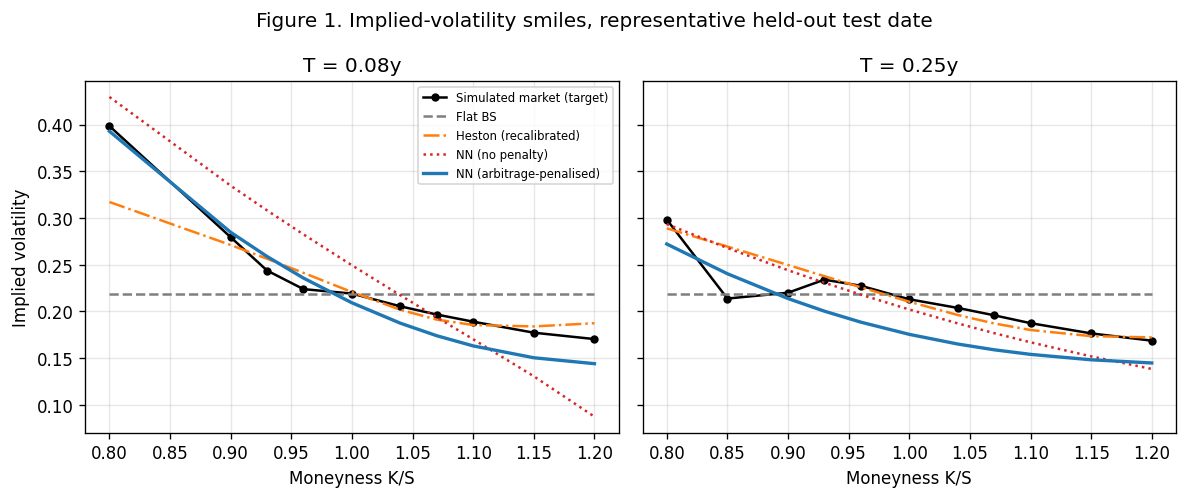

In [25]:
# Figure 1: smiles on a representative test date
rep_day = test_days[len(test_days) // 2]
g = test_df[test_df["day"] == rep_day].sort_values(["T", "moneyness"])
flatbs_series = pd.Series(flatbs_test_iv, index=test_df.index)
heston_recal_series = pd.Series(heston_recal_test_iv, index=test_df.index)
nn_plain_series = pd.Series(nn_plain_test_iv, index=test_df.index)
nn_arb_series = pd.Series(nn_arb_test_iv, index=test_df.index)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
for ax, T_pick in zip(axes, sorted(g["T"].unique())[:2]):
    gt = g[np.isclose(g["T"], T_pick)]; idx = gt.index
    ax.plot(gt["moneyness"], gt["iv"], "ko-", label="Simulated market (target)", ms=4)
    ax.plot(gt["moneyness"], flatbs_series.loc[idx], "--", label="Flat BS", color="tab:gray")
    ax.plot(gt["moneyness"], heston_recal_series.loc[idx], "-.", label="Heston (recalibrated)", color="tab:orange")
    ax.plot(gt["moneyness"], nn_plain_series.loc[idx], ":", label="NN (no penalty)", color="tab:red")
    ax.plot(gt["moneyness"], nn_arb_series.loc[idx], "-", label="NN (arbitrage-penalised)", color="tab:blue", lw=2)
    ax.set_title(f"T = {T_pick:.2f}y"); ax.set_xlabel("Moneyness K/S")
axes[0].set_ylabel("Implied volatility"); axes[0].legend(fontsize=7)
fig.suptitle("Figure 1. Implied-volatility smiles, representative held-out test date")
plt.tight_layout(); plt.show()


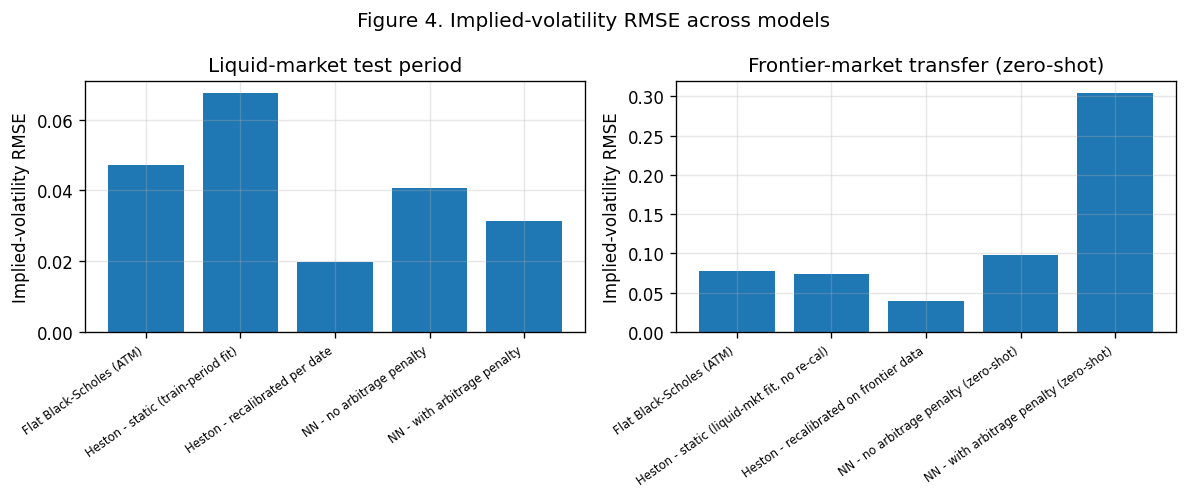

In [26]:
# Figure 4: RMSE comparison, liquid test vs frontier transfer
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, res, title in [(axes[0], table1, "Liquid-market test period"),
                        (axes[1], table5, "Frontier-market transfer (zero-shot)")]:
    x = np.arange(len(res))
    ax.bar(x, res["iv_rmse"], color="tab:blue")
    ax.set_xticks(x); ax.set_xticklabels(res["model"], rotation=35, ha="right", fontsize=7)
    ax.set_ylabel("Implied-volatility RMSE"); ax.set_title(title)
fig.suptitle("Figure 4. Implied-volatility RMSE across models")
plt.tight_layout(); plt.show()


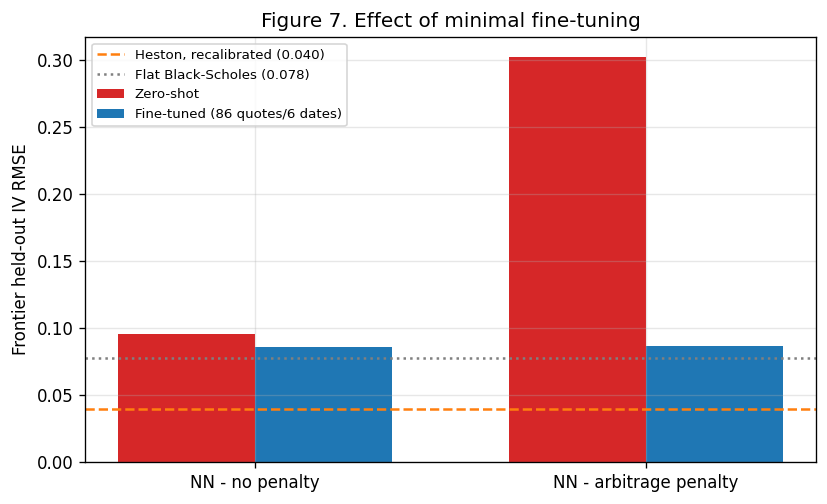

In [27]:
# Figure 7: fine-tuning effect
fig, ax = plt.subplots(figsize=(7, 4.3))
x = np.arange(len(table6)); w = 0.35
ax.bar(x - w/2, table6["iv_rmse_zero_shot"], width=w, label="Zero-shot", color="tab:red")
ax.bar(x + w/2, table6["iv_rmse_finetuned"], width=w, label=f"Fine-tuned ({len(ft_df)} quotes/{n_ft_dates} dates)", color="tab:blue")
heston_recal_val = table5.loc[table5["model"] == "Heston - recalibrated on frontier data", "iv_rmse"].values[0]
flatbs_val = table5.loc[table5["model"] == "Flat Black-Scholes (ATM)", "iv_rmse"].values[0]
ax.axhline(heston_recal_val, ls="--", color="tab:orange", label=f"Heston, recalibrated ({heston_recal_val:.3f})")
ax.axhline(flatbs_val, ls=":", color="gray", label=f"Flat Black-Scholes ({flatbs_val:.3f})")
ax.set_xticks(x); ax.set_xticklabels(table6["model"])
ax.set_ylabel("Frontier held-out IV RMSE"); ax.set_title("Figure 7. Effect of minimal fine-tuning")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 11. Summary

| Finding | Evidence |
|---|---|
| A well-tuned no-arbitrage penalty improves in-domain accuracy | Table 1: IV RMSE 0.0314 (with penalty) vs 0.0407 (without) |
| ...and reduces (but does not eliminate) arbitrage violations | Table 4: butterfly violations 5.0% (with) vs 9.0% (without) |
| A recalibrated Heston model remains the single best benchmark | Table 1 & 5: lowest RMSE on both liquid test and frontier data |
| Neural networks generalise poorly, zero-shot, to a structurally different market | Table 5: both networks underperform even flat Black-Scholes |
| The arbitrage penalty can make zero-shot transfer *worse*, not better | Table 5: penalised network RMSE 0.304 vs 0.098 (unpenalised) |
| Minimal fine-tuning substantially closes the transfer gap | Table 6: both networks converge to ~0.086-0.087 after 86 quotes |

See the manuscript for the full discussion, limitations, and practical
implications for real-time pricing and hedging desks.
